# Feature Engineering — Biodiesel Demand Forecasting
## Repsol Capstone Project — Sprint 2

**Goal:** Combine CORES biodiesel targets with INE macro features to build the model-ready dataset.

**Inputs:**
- `data/processed/biodiesel_targets.csv` — 5 target series × 36 months
- `data/processed/macro_features.csv` — 4 INE macro variables × 36 months

**Features created:**

| Group | Features | Notes |
|-------|----------|-------|
| Calendar | Mes, Trimestre, Año, Tendencia, sin_mes, cos_mes | Cyclical encoding prevents month 12 being "far" from month 1 |
| Target lags | Lag_1, Lag_2, Lag_3, Lag_12 | Lag_12 leaves 24 usable rows per target |
| Rolling | Roll_mean_3, Roll_mean_6, Roll_std_3 | Window over t-1 to t-n (no data leakage) |
| Macro levels | IPI_original, IPI_ajustado, IPC_var_anual, Tasa_paro | From INE API |
| Macro lags | IPI_lag1, IPI_ajustado_lag1, IPC_lag1, Tasa_paro_lag1 | 1-month lag to avoid look-ahead |

**Outputs:**
- `data/processed/model_dataset.csv` — long format, all targets, all features
- `data/processed/train.csv` / `data/processed/test.csv` — temporal split

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

NOTEBOOK_DIR   = Path().resolve()
REPO_ROOT      = NOTEBOOK_DIR.parent
DATA_INPUTS   = REPO_ROOT / 'data' / 'inputs'
DATA_FEATURES = REPO_ROOT / 'data' / 'features'
DATA_OUTPUTS  = REPO_ROOT / 'data' / 'outputs'
FIGURES        = REPO_ROOT / 'reports' / 'figures'

# Temporal split: train on 2023-2024, test on 2025
TRAIN_END = '2024-12'
TEST_START = '2025-01'

print(f"Train: 2023-01 → {TRAIN_END}  ({24} months)")
print(f"Test : {TEST_START} → 2025-12  (12 months)")

Train: 2023-01 → 2024-12  (24 months)
Test : 2025-01 → 2025-12  (12 months)


## 1. Load Inputs

### What?
Load the two processed files and do a quick sanity check.

### Why?
Confirming shape and date alignment before building features avoids propagating upstream errors silently.

In [2]:
# Load master dataset and reconstruct df_targets + df_macro from it
master = pd.read_csv(DATA_INPUTS / 'master_dataset.csv')

TARGET_LABEL = {
    'ESPAÑA':               'Nacional',
    'Andalucía':            'Andalucía',
    'Cataluña':             'Cataluña',
    'Madrid, Comunidad de': 'Madrid',
    'Comunitat Valenciana': 'Valencia',
}

# 5 target series — same interface as original consumo_biodiesel_targets.csv
df_targets = (
    master[master['Target'] == 1][['Fecha', 'CCAA', 'Consumo_Tm']]
    .copy()
    .assign(Target=lambda d: d['CCAA'].map(TARGET_LABEL))
)

# National macro indicators — one row per month (broadcast from ESPAÑA row)
macro_cols = ['IPI_original', 'IPI_ajustado', 'IPC_var_anual', 'Tasa_paro']
df_macro = (
    master[master['CCAA'] == 'ESPAÑA'][['Fecha'] + macro_cols]
    .drop_duplicates('Fecha')
    .reset_index(drop=True)
)

print("targets shape:", df_targets.shape)
print("targets cols :", df_targets.columns.tolist())
print("macro shape  :", df_macro.shape)
print("macro cols   :", df_macro.columns.tolist())
print()

target_dates = set(df_targets['Fecha'].unique())
macro_dates  = set(df_macro['Fecha'].unique())
missing_in_macro = target_dates - macro_dates
print(f"Dates in targets not in macro: {missing_in_macro if missing_in_macro else 'None — aligned'}")
print()
print("Targets available:", df_targets['Target'].unique())

targets shape: (180, 4)
targets cols : ['Fecha', 'CCAA', 'Consumo_Tm', 'Target']
macro shape  : (36, 5)
macro cols   : ['Fecha', 'IPI_original', 'IPI_ajustado', 'IPC_var_anual', 'Tasa_paro']

Dates in targets not in macro: None — aligned

Targets available: ['Nacional' 'Andalucía' 'Cataluña' 'Valencia' 'Madrid']


## 2. Calendar Features

### What?
Extract time-based features from the `Fecha` column.

### Why?
- **Mes / Trimestre / Año**: capture seasonal and annual patterns directly.
- **Tendencia**: integer index 1-36 lets linear models learn the overall growth trend.
- **sin_mes / cos_mes**: cyclical encoding ensures the model knows month 12 and month 1 are adjacent — a plain integer encoding treats them as maximally different.

In [3]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['Fecha_dt']  = pd.to_datetime(df['Fecha'])
    df['Mes']       = df['Fecha_dt'].dt.month
    df['Trimestre'] = df['Fecha_dt'].dt.quarter
    df['Año']       = df['Fecha_dt'].dt.year

    # Linear trend index per target (1 = Jan 2023, 36 = Dec 2025)
    df = df.sort_values(['Target', 'Fecha']).reset_index(drop=True)
    df['Tendencia'] = df.groupby('Target').cumcount() + 1

    # Cyclical encoding of month
    df['sin_mes'] = np.sin(2 * np.pi * df['Mes'] / 12)
    df['cos_mes'] = np.cos(2 * np.pi * df['Mes'] / 12)

    df.drop(columns=['Fecha_dt'], inplace=True)
    return df


df_feat = add_calendar_features(df_targets)

print("Calendar features added:")
print(df_feat[df_feat['Target'] == 'Nacional'].head(6)[[
    'Fecha', 'Mes', 'Trimestre', 'Año', 'Tendencia', 'sin_mes', 'cos_mes'
]].to_string(index=False))

Calendar features added:
  Fecha  Mes  Trimestre  Año  Tendencia      sin_mes       cos_mes
2023-01    1          1 2023          1 5.000000e-01  8.660254e-01
2023-02    2          1 2023          2 8.660254e-01  5.000000e-01
2023-03    3          1 2023          3 1.000000e+00  6.123234e-17
2023-04    4          2 2023          4 8.660254e-01 -5.000000e-01
2023-05    5          2 2023          5 5.000000e-01 -8.660254e-01
2023-06    6          2 2023          6 1.224647e-16 -1.000000e+00


## 3. Lag Features (Target)

### What?
Create lagged values of `Consumo_Tm` within each target series: Lag_1, Lag_2, Lag_3, Lag_12.

### Why?
Lagged consumption is the single strongest predictor of current consumption in most time series. Lags must be computed **per target** (not across the whole DataFrame) to avoid leakage between regions.

**Data budget note:**
- Lag_3 → loses first 3 months → **33 usable rows** per target  
- Lag_12 → loses first 12 months → **24 usable rows** per target (but captures seasonal pattern)

Both are kept in the dataset; each model will drop rows with NaN in the features it uses.

In [4]:
def add_lag_features(df: pd.DataFrame, lags: list) -> pd.DataFrame:
    df = df.sort_values(['Target', 'Fecha']).reset_index(drop=True)
    for lag in lags:
        col = f'Lag_{lag}'
        df[col] = df.groupby('Target')['Consumo_Tm'].shift(lag)
    return df


df_feat = add_lag_features(df_feat, lags=[1, 2, 3, 12])

print("Lag features — Nacional (first 15 rows):")
print(df_feat[df_feat['Target'] == 'Nacional'][[
    'Fecha', 'Consumo_Tm', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_12'
]].head(15).to_string(index=False))

print()
print("NaN count from lags (Nacional):")
nac = df_feat[df_feat['Target'] == 'Nacional']
print(nac[['Lag_1', 'Lag_2', 'Lag_3', 'Lag_12']].isnull().sum())

Lag features — Nacional (first 15 rows):
  Fecha  Consumo_Tm  Lag_1  Lag_2  Lag_3  Lag_12
2023-01         167    NaN    NaN    NaN     NaN
2023-02         162  167.0    NaN    NaN     NaN
2023-03         205  162.0  167.0    NaN     NaN
2023-04         260  205.0  162.0  167.0     NaN
2023-05         431  260.0  205.0  162.0     NaN
2023-06         379  431.0  260.0  205.0     NaN
2023-07         257  379.0  431.0  260.0     NaN
2023-08         525  257.0  379.0  431.0     NaN
2023-09         389  525.0  257.0  379.0     NaN
2023-10         520  389.0  525.0  257.0     NaN
2023-11        1152  520.0  389.0  525.0     NaN
2023-12        1570 1152.0  520.0  389.0     NaN
2024-01         546 1570.0 1152.0  520.0   167.0
2024-02        1131  546.0 1570.0 1152.0   162.0
2024-03        1698 1131.0  546.0 1570.0   205.0

NaN count from lags (Nacional):
Lag_1      1
Lag_2      2
Lag_3      3
Lag_12    12
dtype: int64


## 4. Rolling Window Features

### What?
Compute rolling mean (3-month, 6-month) and rolling standard deviation (3-month) of `Consumo_Tm` within each target.

### Why?
- **Rolling mean**: smoothed trend signal that captures medium-term momentum.
- **Rolling std**: volatility indicator — high std months may be harder to predict and useful for model uncertainty.
- `closed='left'` ensures the window uses only past values (t-n to t-1), never the current observation — no leakage.

In [5]:
def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['Target', 'Fecha']).reset_index(drop=True)

    for target, grp in df.groupby('Target'):
        idx = grp.index
        # shift(1) so window ends at t-1 (no look-ahead)
        shifted = grp['Consumo_Tm'].shift(1)
        df.loc[idx, 'Roll_mean_3'] = shifted.rolling(window=3, min_periods=2).mean()
        df.loc[idx, 'Roll_mean_6'] = shifted.rolling(window=6, min_periods=3).mean()
        df.loc[idx, 'Roll_std_3']  = shifted.rolling(window=3, min_periods=2).std()

    return df


df_feat = add_rolling_features(df_feat)

print("Rolling features — Nacional:")
print(df_feat[df_feat['Target'] == 'Nacional'][[
    'Fecha', 'Consumo_Tm', 'Roll_mean_3', 'Roll_mean_6', 'Roll_std_3'
]].head(10).to_string(index=False))

Rolling features — Nacional:
  Fecha  Consumo_Tm  Roll_mean_3  Roll_mean_6  Roll_std_3
2023-01         167          NaN          NaN         NaN
2023-02         162          NaN          NaN         NaN
2023-03         205   164.500000          NaN    3.535534
2023-04         260   178.000000   178.000000   23.515952
2023-05         431   209.000000   198.500000   49.122296
2023-06         379   298.666667   245.000000  117.857258
2023-07         257   356.666667   267.333333   87.660329
2023-08         525   355.666667   282.333333   89.315919
2023-09         389   387.000000   342.833333  134.178985
2023-10         520   390.333333   373.500000  134.004975


## 5. Merge Macro Features

### What?
Join the INE macro variables onto the feature DataFrame, then create 1-month lags of the macro variables.

### Why?
Using macro values at time t assumes they were available at time t. In practice, IPI and IPC are published with a 1-2 month delay. Adding `_lag1` versions is both more realistic for a production forecasting model and avoids any potential look-ahead bias.

In [6]:
macro_cols = ['IPI_original', 'IPI_ajustado', 'IPC_var_anual', 'Tasa_paro']

# Merge macro onto long-format feature dataset
df_feat = df_feat.merge(df_macro[['Fecha'] + macro_cols], on='Fecha', how='left')

# Add 1-month lags of macro variables (publication delay proxy)
# Sort by Target + Fecha so shift works correctly within each group
df_feat = df_feat.sort_values(['Target', 'Fecha']).reset_index(drop=True)
for col in macro_cols:
    df_feat[f'{col}_lag1'] = df_feat.groupby('Target')[col].shift(1)

print("Macro features merged. Sample:")
print(df_feat[df_feat['Target'] == 'Nacional'][[
    'Fecha', 'IPI_original', 'IPI_original_lag1', 'IPC_var_anual', 'Tasa_paro'
]].head(6).to_string(index=False))
print()
print("Total columns:", df_feat.shape[1])
print("All columns:")
print(df_feat.columns.tolist())

Macro features merged. Sample:
  Fecha  IPI_original  IPI_original_lag1  IPC_var_anual  Tasa_paro
2023-01        97.874                NaN            5.9      11.67
2023-02        99.947             97.874            6.0      11.67
2023-03       113.733             99.947            3.3      11.67
2023-04        93.271            113.733            4.1      11.89
2023-05       108.291             93.271            3.2      11.89
2023-06       106.840            108.291            1.9      11.89

Total columns: 25
All columns:
['Fecha', 'CCAA', 'Consumo_Tm', 'Target', 'Mes', 'Trimestre', 'Año', 'Tendencia', 'sin_mes', 'cos_mes', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_12', 'Roll_mean_3', 'Roll_mean_6', 'Roll_std_3', 'IPI_original', 'IPI_ajustado', 'IPC_var_anual', 'Tasa_paro', 'IPI_original_lag1', 'IPI_ajustado_lag1', 'IPC_var_anual_lag1', 'Tasa_paro_lag1']


## 6. Null Summary

### What?
Audit which rows and features have NaN values and explain their origin.

### Why?
Each model in Sprint 3 will handle NaNs differently — ARIMA ignores lag columns entirely, while XGBoost/RF can optionally handle them. Documenting the null structure here prevents surprises downstream.

In [7]:
null_summary = df_feat.isnull().sum()
null_summary = null_summary[null_summary > 0].sort_values(ascending=False)

print("=" * 60)
print("NULL COUNT PER FEATURE (across all 5 targets × 36 months = 180 rows)")
print("=" * 60)
print(null_summary.to_string())
print()

# Rows with NO nulls (usable for all models including Lag_12)
full_rows = df_feat.dropna().shape[0]
# Rows usable without Lag_12
no_lag12_cols = [c for c in df_feat.columns if c != 'Lag_12']
rows_no_lag12 = df_feat[no_lag12_cols].dropna().shape[0]

print(f"Rows with all features complete (incl. Lag_12): {full_rows} / 180")
print(f"  → {full_rows // 5} months per target (months 13-36)")
print()
print(f"Rows complete excluding Lag_12:                 {rows_no_lag12} / 180")
print(f"  → {rows_no_lag12 // 5} months per target (months 4-36)")
print()
print("Origin of nulls:")
print("  Lag_1/2/3        → first 1/2/3 months have no history")
print("  Lag_12           → first 12 months have no same-month-prior-year value")
print("  Roll_mean/std    → first 2-6 months (rolling window not yet full)")
print("  *_lag1 (macro)   → first month per target (no prior macro value)")

NULL COUNT PER FEATURE (across all 5 targets × 36 months = 180 rows)
Lag_12                60
Lag_3                 15
Roll_mean_6           15
Lag_2                 10
Roll_mean_3           10
Roll_std_3            10
Lag_1                  5
IPI_original_lag1      5
IPI_ajustado_lag1      5
IPC_var_anual_lag1     5
Tasa_paro_lag1         5

Rows with all features complete (incl. Lag_12): 120 / 180
  → 24 months per target (months 13-36)

Rows complete excluding Lag_12:                 165 / 180
  → 33 months per target (months 4-36)

Origin of nulls:
  Lag_1/2/3        → first 1/2/3 months have no history
  Lag_12           → first 12 months have no same-month-prior-year value
  Roll_mean/std    → first 2-6 months (rolling window not yet full)
  *_lag1 (macro)   → first month per target (no prior macro value)


## 7. Feature Visualisation

### What?
Two plots: (1) all engineered features for the Nacional series as a heatmap; (2) correlation of each feature with Consumo_Tm across all targets.

### Why?
The heatmap reveals co-linear features before they enter a model. The correlation bar chart gives a quick signal of which features are worth prioritising.

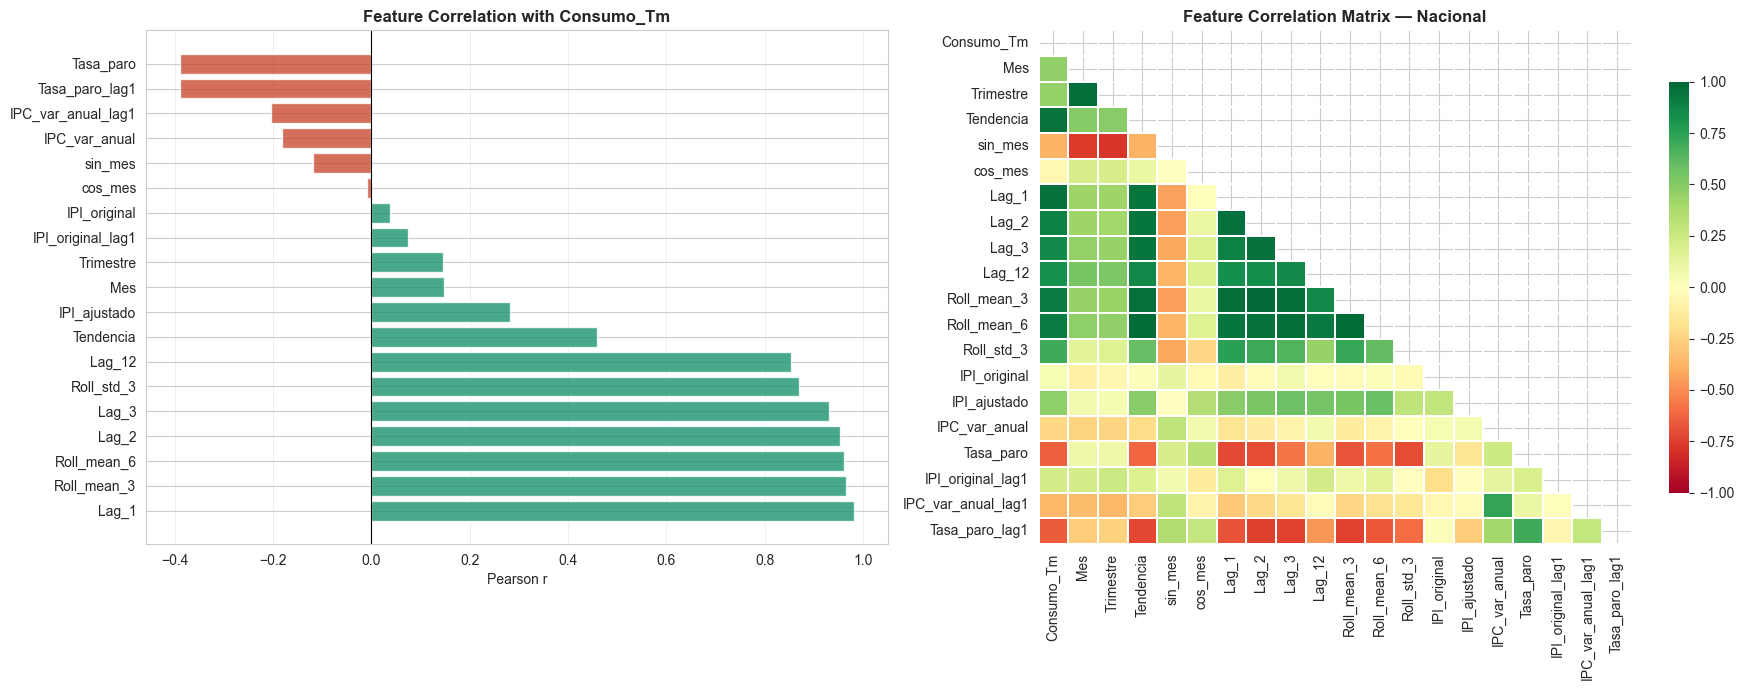

Figure saved: 09_feature_correlations.png

Top 5 features by absolute correlation with Consumo_Tm:
Lag_1          0.982
Roll_mean_3    0.967
Roll_mean_6    0.961
Lag_2          0.954
Lag_3          0.932


In [8]:
numeric_cols = [
    'Consumo_Tm',
    'Mes', 'Trimestre', 'Tendencia', 'sin_mes', 'cos_mes',
    'Lag_1', 'Lag_2', 'Lag_3', 'Lag_12',
    'Roll_mean_3', 'Roll_mean_6', 'Roll_std_3',
    'IPI_original', 'IPI_ajustado', 'IPC_var_anual', 'Tasa_paro',
    'IPI_original_lag1', 'IPC_var_anual_lag1', 'Tasa_paro_lag1',
]

# Correlation of each feature with Consumo_Tm (all targets pooled)
corr_with_target = (
    df_feat[numeric_cols]
    .corr()['Consumo_Tm']
    .drop('Consumo_Tm')
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Correlation with target
colors = ['#1A936F' if v >= 0 else '#C84B31' for v in corr_with_target.values]
axes[0].barh(corr_with_target.index, corr_with_target.values, color=colors, alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with Consumo_Tm', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pearson r')
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Feature correlation matrix (Nacional only, drop high-NA cols)
df_nac = df_feat[df_feat['Target'] == 'Nacional'][numeric_cols].dropna()
corr_matrix = df_nac.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False, cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, ax=axes[1],
    linewidths=0.3, cbar_kws={'shrink': 0.8}
)
axes[1].set_title('Feature Correlation Matrix — Nacional', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / '09_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 09_feature_correlations.png")
print()
print("Top 5 features by absolute correlation with Consumo_Tm:")
print(corr_with_target.abs().sort_values(ascending=False).head(5).round(3).to_string())

## 8. Temporal Train / Test Split

### What?
Split the dataset temporally: train = 2023-01 to 2024-12, test = 2025-01 to 2025-12.

### Why?
A temporal split (not random) is mandatory for time series — random splitting would leak future data into the training set. The last 12 months (2025) serve as a realistic holdout: models are trained on 2 years of history and evaluated on the most recent year before the actual 24-month forecast into 2026-2027.

**Effective training rows per target after dropping NaN:**
- Without Lag_12: rows 4-24 = **21 months** per target
- With Lag_12: rows 13-24 = **12 months** per target (very limited — use with care)

TRAIN / TEST SPLIT
Train: 2023-01 → 2024-12  (120 rows total, 24 per target)
Test : 2025-01 → 2025-12  (60 rows total, 12 per target)

Usable train rows per target (after dropna on Lag_1..3 + rolling):
  Andalucía: 21 months
  Cataluña: 21 months
  Madrid: 21 months
  Nacional: 21 months
  Valencia: 21 months



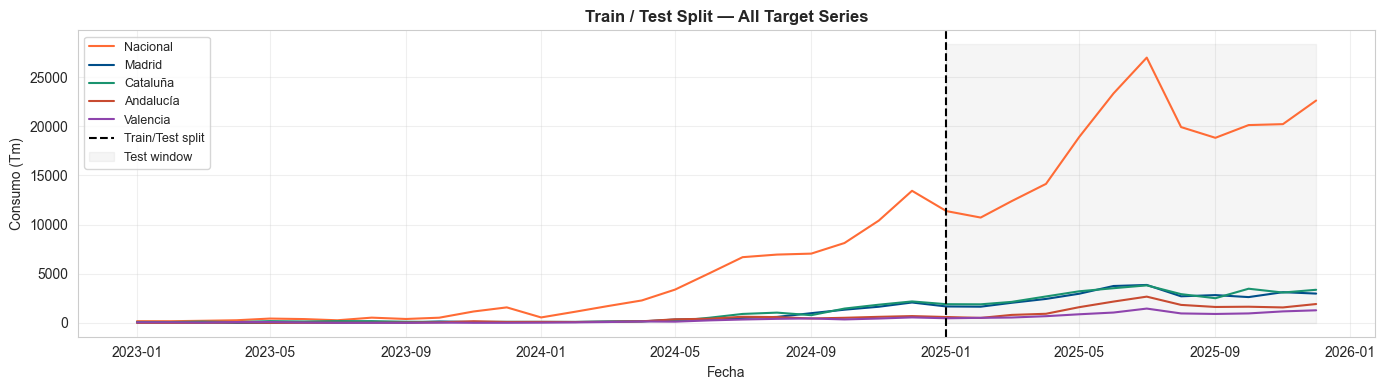

Figure saved: 10_train_test_split.png


In [9]:
df_train = df_feat[df_feat['Fecha'] <= TRAIN_END].copy()
df_test  = df_feat[df_feat['Fecha'] >= TEST_START].copy()

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)
print(f"Train: {df_train['Fecha'].min()} → {df_train['Fecha'].max()}  ({len(df_train)} rows total, {len(df_train)//5} per target)")
print(f"Test : {df_test['Fecha'].min()} → {df_test['Fecha'].max()}  ({len(df_test)} rows total, {len(df_test)//5} per target)")
print()

# Usable training rows per target (after dropping lag NaNs)
print("Usable train rows per target (after dropna on Lag_1..3 + rolling):")
base_feat_cols = [
    'Lag_1', 'Lag_2', 'Lag_3',
    'Roll_mean_3', 'Roll_mean_6',
    'IPI_original', 'IPC_var_anual', 'Tasa_paro'
]
for target in df_train['Target'].unique():
    sub = df_train[df_train['Target'] == target][base_feat_cols + ['Consumo_Tm']].dropna()
    print(f"  {target}: {len(sub)} months")

print()
# Visualise the split
fig, ax = plt.subplots(figsize=(14, 4))
for target, color in zip(
    ['Nacional', 'Madrid', 'Cataluña', 'Andalucía', 'Valencia'],
    ['#FF6B35', '#004E89', '#1A936F', '#C84B31', '#8E44AD']
):
    sub = df_feat[df_feat['Target'] == target].copy()
    sub['Fecha_dt'] = pd.to_datetime(sub['Fecha'])
    ax.plot(sub['Fecha_dt'], sub['Consumo_Tm'], label=target, color=color, linewidth=1.5)

split_date = pd.to_datetime('2025-01')
ax.axvline(split_date, color='black', linestyle='--', linewidth=1.5, label='Train/Test split')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 30000],
                  split_date, pd.to_datetime('2025-12'), alpha=0.08, color='grey', label='Test window')
ax.set_title('Train / Test Split — All Target Series', fontsize=12, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Consumo (Tm)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / '10_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 10_train_test_split.png")

## 9. Save Outputs

### What?
Save three files: the full feature dataset, the training split, and the test split.

### Why?
Having separate files for each split ensures the modelling notebook (`05_modeling.ipynb`) can load train/test directly without re-running feature engineering — and avoids any risk of accidentally training on test data.

In [10]:
out_full  = DATA_FEATURES / 'features_modelo_completo.csv'
out_train = DATA_FEATURES / 'features_train.csv'
out_test  = DATA_FEATURES / 'features_test.csv'

df_feat.to_csv(out_full,  index=False, encoding='utf-8')
df_train.to_csv(out_train, index=False, encoding='utf-8')
df_test.to_csv(out_test,  index=False, encoding='utf-8')

print(f"Saved: {out_full.name}   ({df_feat.shape[0]} rows × {df_feat.shape[1]} cols)")
print(f"Saved: {out_train.name}  ({df_train.shape[0]} rows × {df_train.shape[1]} cols)")
print(f"Saved: {out_test.name}   ({df_test.shape[0]} rows × {df_test.shape[1]} cols)")
print()
print("Final column list:")
for i, col in enumerate(df_feat.columns, 1):
    print(f"  {i:2d}. {col}")

Saved: features_modelo_completo.csv   (180 rows × 25 cols)
Saved: features_train.csv  (120 rows × 25 cols)
Saved: features_test.csv   (60 rows × 25 cols)

Final column list:
   1. Fecha
   2. CCAA
   3. Consumo_Tm
   4. Target
   5. Mes
   6. Trimestre
   7. Año
   8. Tendencia
   9. sin_mes
  10. cos_mes
  11. Lag_1
  12. Lag_2
  13. Lag_3
  14. Lag_12
  15. Roll_mean_3
  16. Roll_mean_6
  17. Roll_std_3
  18. IPI_original
  19. IPI_ajustado
  20. IPC_var_anual
  21. Tasa_paro
  22. IPI_original_lag1
  23. IPI_ajustado_lag1
  24. IPC_var_anual_lag1
  25. Tasa_paro_lag1


## 10. Summary

### Sprint 2 — Feature Engineering: DONE ✅

| Feature group | Count | Key insight |
|---------------|-------|-------------|
| Calendar | 5 | Tendencia + sin/cos capture trend + cyclical pattern |
| Lag (target) | 4 | Lag_1 likely strongest predictor; Lag_12 gives YoY signal |
| Rolling | 3 | Roll_mean_6 smooths out monthly noise |
| Macro levels | 4 | IPI and Tasa_paro — check correlation chart for actual signal |
| Macro lags | 4 | Publication-delay-aware versions |
| **Total** | **20** | — |

**Data constraint reminder:** With only 36 months per target, training windows are small:
- Models using Lag_1-3 + rolling: **21 training obs per target**
- Models using Lag_12: **12 training obs per target** — use with caution

**Recommendation for modeling:**
- ARIMA/SARIMA: use raw `Consumo_Tm` series (handles lags internally)
- Regresión Lineal: use calendar + macro features (no lags needed)
- Random Forest / XGBoost: use base features + Lag_1-3 + Roll_mean_3/6 (drop Lag_12)

### Next step → `05_modeling.ipynb`
Train and evaluate ARIMA, Linear Regression, Random Forest, and XGBoost for each of the 5 target series. Output: predictions + MAE/RMSE/MAPE/R² metrics.